In [10]:
import pandas as pd
import json
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import seaborn as sns

In [11]:
with open("/media/EVO870/datasets/prompting-mammalps-v2/metadata/queries_and_videos_test.json", "r") as f:
    queries_and_videos = json.load(f)

In [14]:
queries = list(queries_and_videos.keys())
len(queries)

135

In [17]:
associated_videos_flat = [v for q in queries_and_videos for v in queries_and_videos[q]]
len(set(associated_videos_flat))

773

In [18]:
queries_videos_df = pd.concat([pd.DataFrame({"queries": list(queries_and_videos.keys()), "videos": list(np.array(q) for q in queries_and_videos.values())})])
queries_videos_df["nb_videos"] = queries_videos_df["videos"].apply(lambda d: len(d))
queries_videos_df["nb_videos"].describe()

count    135.000000
mean      20.844444
std       47.578351
min        0.000000
25%        2.000000
50%        5.000000
75%       21.500000
max      373.000000
Name: nb_videos, dtype: float64

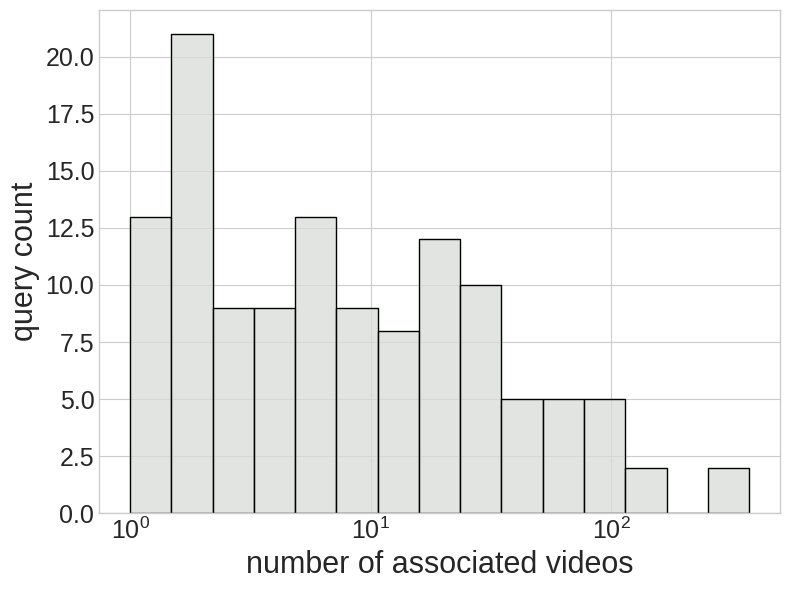

12 queries with no video associated to them


In [20]:
nb_videos_per_query = (queries_videos_df["nb_videos"].values)
nb_videos_per_query = (queries_videos_df["nb_videos"].values)

# use a clean / conference‑style theme
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    nb_videos_per_query,
    bins=15,
    ax=ax,
    log_scale=True,
    color="xkcd:light grey", 
    edgecolor="black",
    element="bars",
)

ax.set_xlabel("number of associated videos", fontsize=22)
ax.set_ylabel("query count", fontsize=22)
ax.tick_params(axis="both", labelsize=18)

#ax.set_title("Distribution of videos per query", fontsize=16)

plt.tight_layout()
fig.savefig("nb_videos_per_query_hist.svg", transparent=True)
plt.show()

print(len(queries_videos_df[queries_videos_df["nb_videos"] == 0]),
      "queries with no video associated to them")

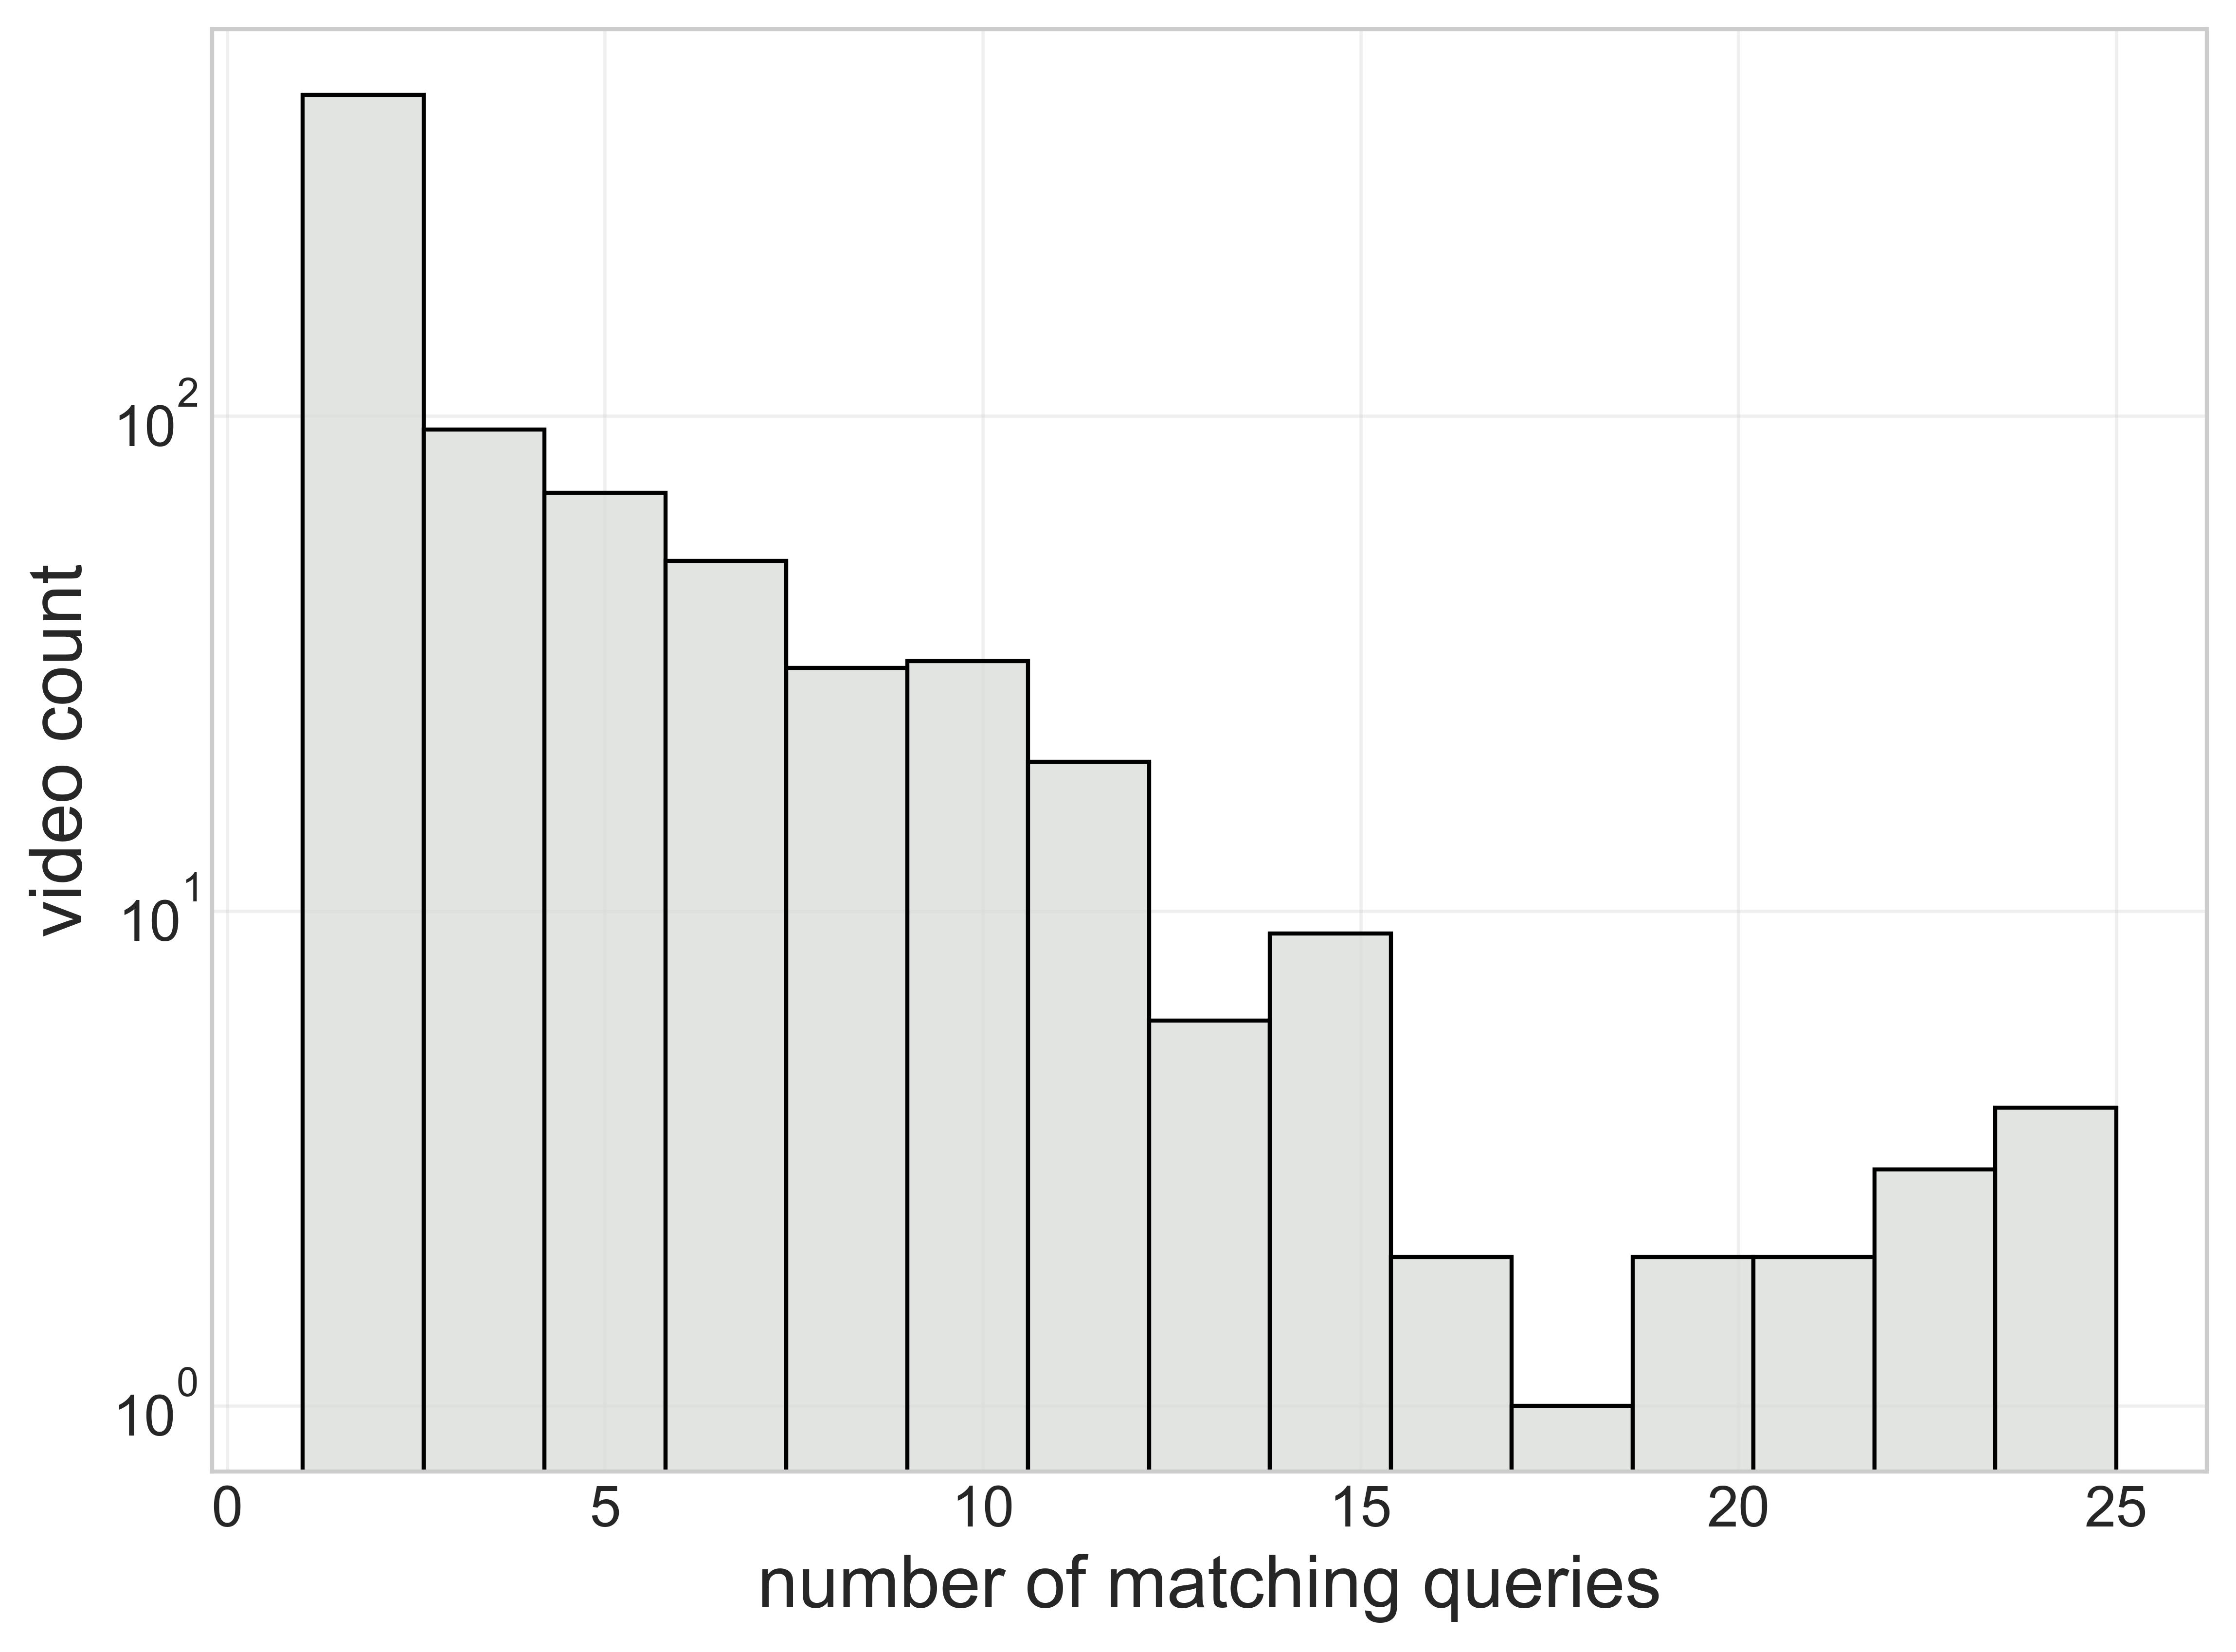

In [66]:
nb_queries_per_video = (queries_videos_df.explode("videos").groupby("videos").agg({"queries": pd.Series.nunique}).values).squeeze()

# use a clean / conference‑style theme
fig, ax = plt.subplots(figsize=(8, 6))

g = sns.histplot(
    nb_queries_per_video,
    bins=15,
    ax=ax,
    log_scale=False,
    element="bars",
    edgecolor="black",
    color="xkcd:light grey",
)
g.set_yscale("log")

ax.set_xlabel("number of matching queries", fontsize=18)
ax.set_ylabel("video count", fontsize=18)
ax.tick_params(axis="both", labelsize=14)
#ax.set_title("Distribution of queries per video", fontsize=16)

plt.tight_layout()
fig.savefig("nb_queries_per_video_hist.svg", transparent=True)
plt.show()

In [67]:
queries_videos_df.explode("videos").groupby("videos").agg({"queries": pd.Series.nunique}).describe()

,queries
count,773.000000
mean,3.640362
std,3.961607
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,25.000000


In [68]:
queries_videos_df.sort_values("nb_videos")

,queries,videos,category,nb_videos
12,A fox sniffing.,[],RARE,0
13,A fox chasing prey.,[],RARE,0
8,A juvenile roe deer preparing to suckle.,[],RARE,0
25,A juvenile roe deer.,[],RARE,0
18,A roe deer participating in courtship in rainy...,[],COURTSHIP,0
...,...,...,...,...
38,Rainy weather.,"[S3_C4_F720_V0085, S3_C4_F720_V0082, S3_C4_F72...",RARE,108
30,An animal being vigilant while the weather is ...,"[S3_C3_E501_V0277, S3_C3_E524_V0327, S3_C3_E50...",SOCIAL,117
15,An animal being vigilant in a different weathe...,"[S3_C3_E515_V0313, S3_C3_E692_V0701, S3_C3_E69...",VIDEO_COMPARISON,120
0,An animal engaged in any activity other than f...,"[S3_C3_E501_V0277, S3_C3_E523_V0324, S3_C3_E51...",RARE,329


In [69]:
queries_videos_df.explode("videos").groupby("videos").agg({"queries": pd.Series.nunique}).sort_values("queries")

,queries
videos,
S3_C5_F719_V0153,1
S1_C1_E117_V0369,1
S1_C1_E118_V0389,1
S1_C1_E118_V0388,1
S1_C1_E118_V0385,1
...,...
S3_C2_E693_V0182,22
S2_C3_F568_V0117,24
S1_C6_F173_V0100,24


In [70]:
print(*queries_videos_df.explode("videos").query("videos == 'S2_C3_F625_V0155'")["queries"].unique(), sep="\n")

In [71]:
queries_videos_df[queries_videos_df["queries"].str.contains("juvenile red deer scratching")]["videos"].values

array([array(['S3_C3_E515_V0313', 'S3_C3_E693_V0702', 'S3_C3_E693_V0704',
              'S3_C3_E693_V0703', 'S3_C2_E515_V0086', 'S1_C6_F394_V0311',
              'S1_C6_F269_V0193', 'S1_C6_F404_V0330', 'S1_C6_F394_V0316',
              'S2_C2_F568_V0083'], dtype='<U16')                         ],
      dtype=object)

## Remaining videos

In [72]:
annotation_paths = list(Path("/media/EVO870/datasets/prompting-mammalps/annotations/test").rglob("*.json"))
all_video_ids = [f.stem for f in annotation_paths]
remaining_ids = set(all_video_ids) - set(associated_videos_flat)

len(remaining_ids)

197

In [73]:
len(set(all_video_ids))

744

In [16]:
with open("../benchmark/query_categories.json", "r") as f:
    queries_cat = json.load(f)

{'RARE': 48, 'SOCIAL': 36, 'CAMERA_REACTION': 28, 'COURTSHIP': 27, 'COMMON': 2}
{'MULTI_ATTR': 92, 'MULTI_INDIV': 25, 'VIDEO_COMPARISON': 22, 'COMPLEX': 15, 'SINGLE_ATTR': 14}


/tmp/ipykernel_366472/2289127026.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('GnBu')
/tmp/ipykernel_366472/2289127026.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdPu')


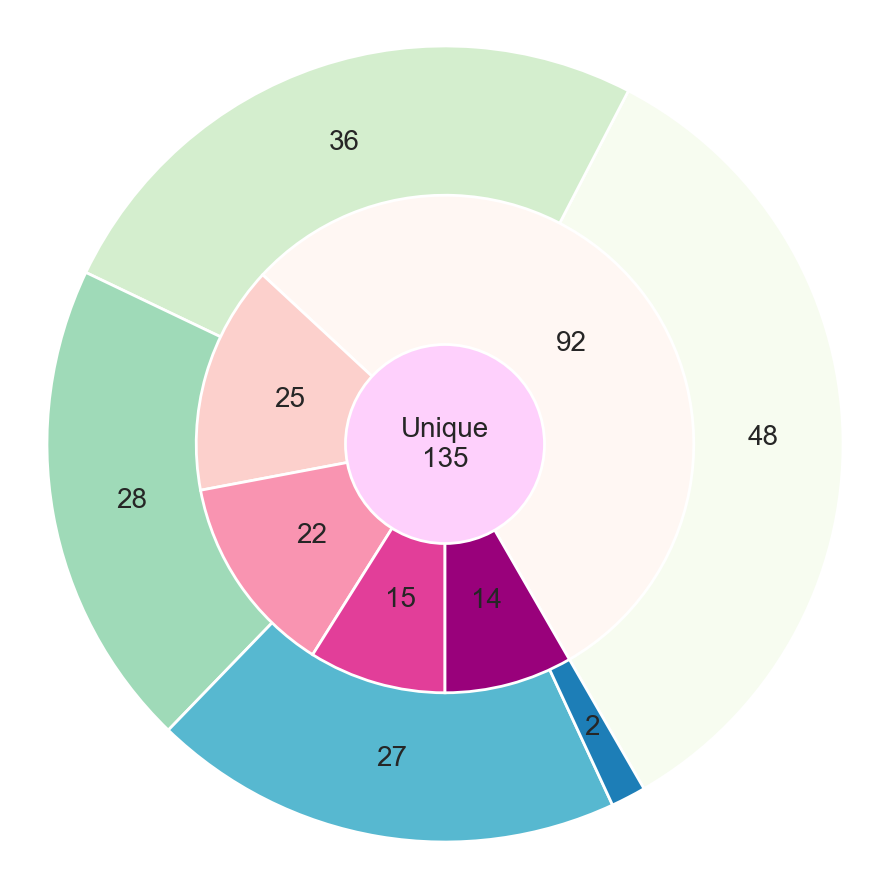

In [20]:
import matplotlib.cm as cm

# Count the number of queries per category
category_counts = {cat: len(queries_cat["ECOLOGY"][cat]) for cat in queries_cat["ECOLOGY"]}
category_counts = {k: v for k, v in sorted(category_counts.items(), key=lambda item: item[1], reverse=True)}
labels = list(category_counts.keys())
sizes = list(category_counts.values())
total_queries = len(queries)
print(category_counts)

# Choose a colormap
cmap = cm.get_cmap('GnBu')
colors = [cmap(i / len(labels)) for i in range(len(labels))]

# Pie chart with number labels and black edge color
fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    sizes,
    #labels=labels,
    radius=.8,
    autopct=lambda pct: f"{int(round(pct * sum(sizes) / 100))}",
    startangle=300,
    pctdistance=.8,
    colors=colors,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

# Increase the font size of the number labels on the pie chart
for autotext in autotexts:
    autotext.set_fontsize(20)  # Adjust the value as needed
# for autotext in autotexts[:-1]:
#    autotext.set_color("white")

category_counts = {cat: len(queries_cat["VISION"][cat]) for cat in queries_cat["VISION"]}
category_counts = {k: v for k, v in sorted(category_counts.items(), key=lambda item: item[1], reverse=True)}
labels = list(category_counts.keys())
sizes = list(category_counts.values())
total_queries = len(queries)

# Choose a colormap
cmap = cm.get_cmap('RdPu')
colors = [cmap(i / len(labels)) for i in range(len(labels))]
print(category_counts)
# Pie chart with number labels and black edge color
wedges, texts, autotexts = ax.pie(
    sizes,
    radius=.5,
    pctdistance=.65,
    autopct=lambda pct: f"{int(round(pct *  sum(sizes) / 100))}",
    startangle=300,
    colors=colors,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

# Increase the font size of the number labels on the pie chart
for autotext in autotexts:
    autotext.set_fontsize(20)  # Adjust the value as needed
# for autotext in autotexts[:-1]:
#     autotext.set_color("white")

# Draw a circle at the center with total number of queries
centre_circle = plt.Circle((0, 0), 0.20, fc="xkcd:pale mauve", ec="white", linewidth=2)
ax.add_artist(centre_circle)
ax.text(0, 0, f"Unique\n{total_queries}", ha='center', va='center', fontsize=20)#, fontweight='bold')

plt.axis('equal')

plt.tight_layout()
fig.savefig("queries_distribution.svg", transparent=True)

plt.show()

## Distribution per split

In [7]:
mpl_config = {
    "figure.figsize": (12, 8),
    "figure.dpi": 600,
    "figure.facecolor": "white",
    "svg.fonttype": "none",

    # Font settings
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.size": 18,

    # Title and Label size
    "axes.titlesize": 20,
    "axes.labelsize": 18,

    # Tick parameters
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Grid and Spines for readability
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.edgecolor": "black",
    "axes.linewidth": 1,

    # Legend
    "legend.fontsize": 12,
    "legend.frameon": True,
    "legend.loc": "best",


}

plt.rcParams.update(mpl_config)

In [3]:
with open("queries_and_videos_train.json", "r") as f:
    queries_and_videos_train = json.load(f)

with open("queries_and_videos_test.json", "r") as f:
    queries_and_videos_test = json.load(f)

In [4]:
queries_videos_train_df = pd.concat([pd.DataFrame({"queries": list(queries_and_videos_train[cat].keys()), "videos": list(np.array(q) for q in queries_and_videos_train[cat].values()), "category": [cat for _ in range(len(queries_and_videos_train[cat].keys()))]}) for cat in queries_and_videos_train])
queries_videos_train_df["nb_videos"] = queries_videos_train_df["videos"].apply(lambda d: len(d))
queries_videos_train_df["nb_videos"].describe()

count     135.000000
mean       57.777778
std       132.988703
min         0.000000
25%         4.000000
50%        16.000000
75%        51.500000
max      1110.000000
Name: nb_videos, dtype: float64

In [5]:
queries_videos_test_df = pd.concat([pd.DataFrame({"queries": list(queries_and_videos_test[cat].keys()), "videos": list(np.array(q) for q in queries_and_videos_test[cat].values()), "category": [cat for _ in range(len(queries_and_videos_test[cat].keys()))]}) for cat in queries_and_videos_test])
queries_videos_test_df["nb_videos"] = queries_videos_test_df["videos"].apply(lambda d: len(d))
queries_videos_test_df["nb_videos"].describe()

count    135.000000
mean      20.844444
std       47.578351
min        0.000000
25%        2.000000
50%        5.000000
75%       21.500000
max      373.000000
Name: nb_videos, dtype: float64

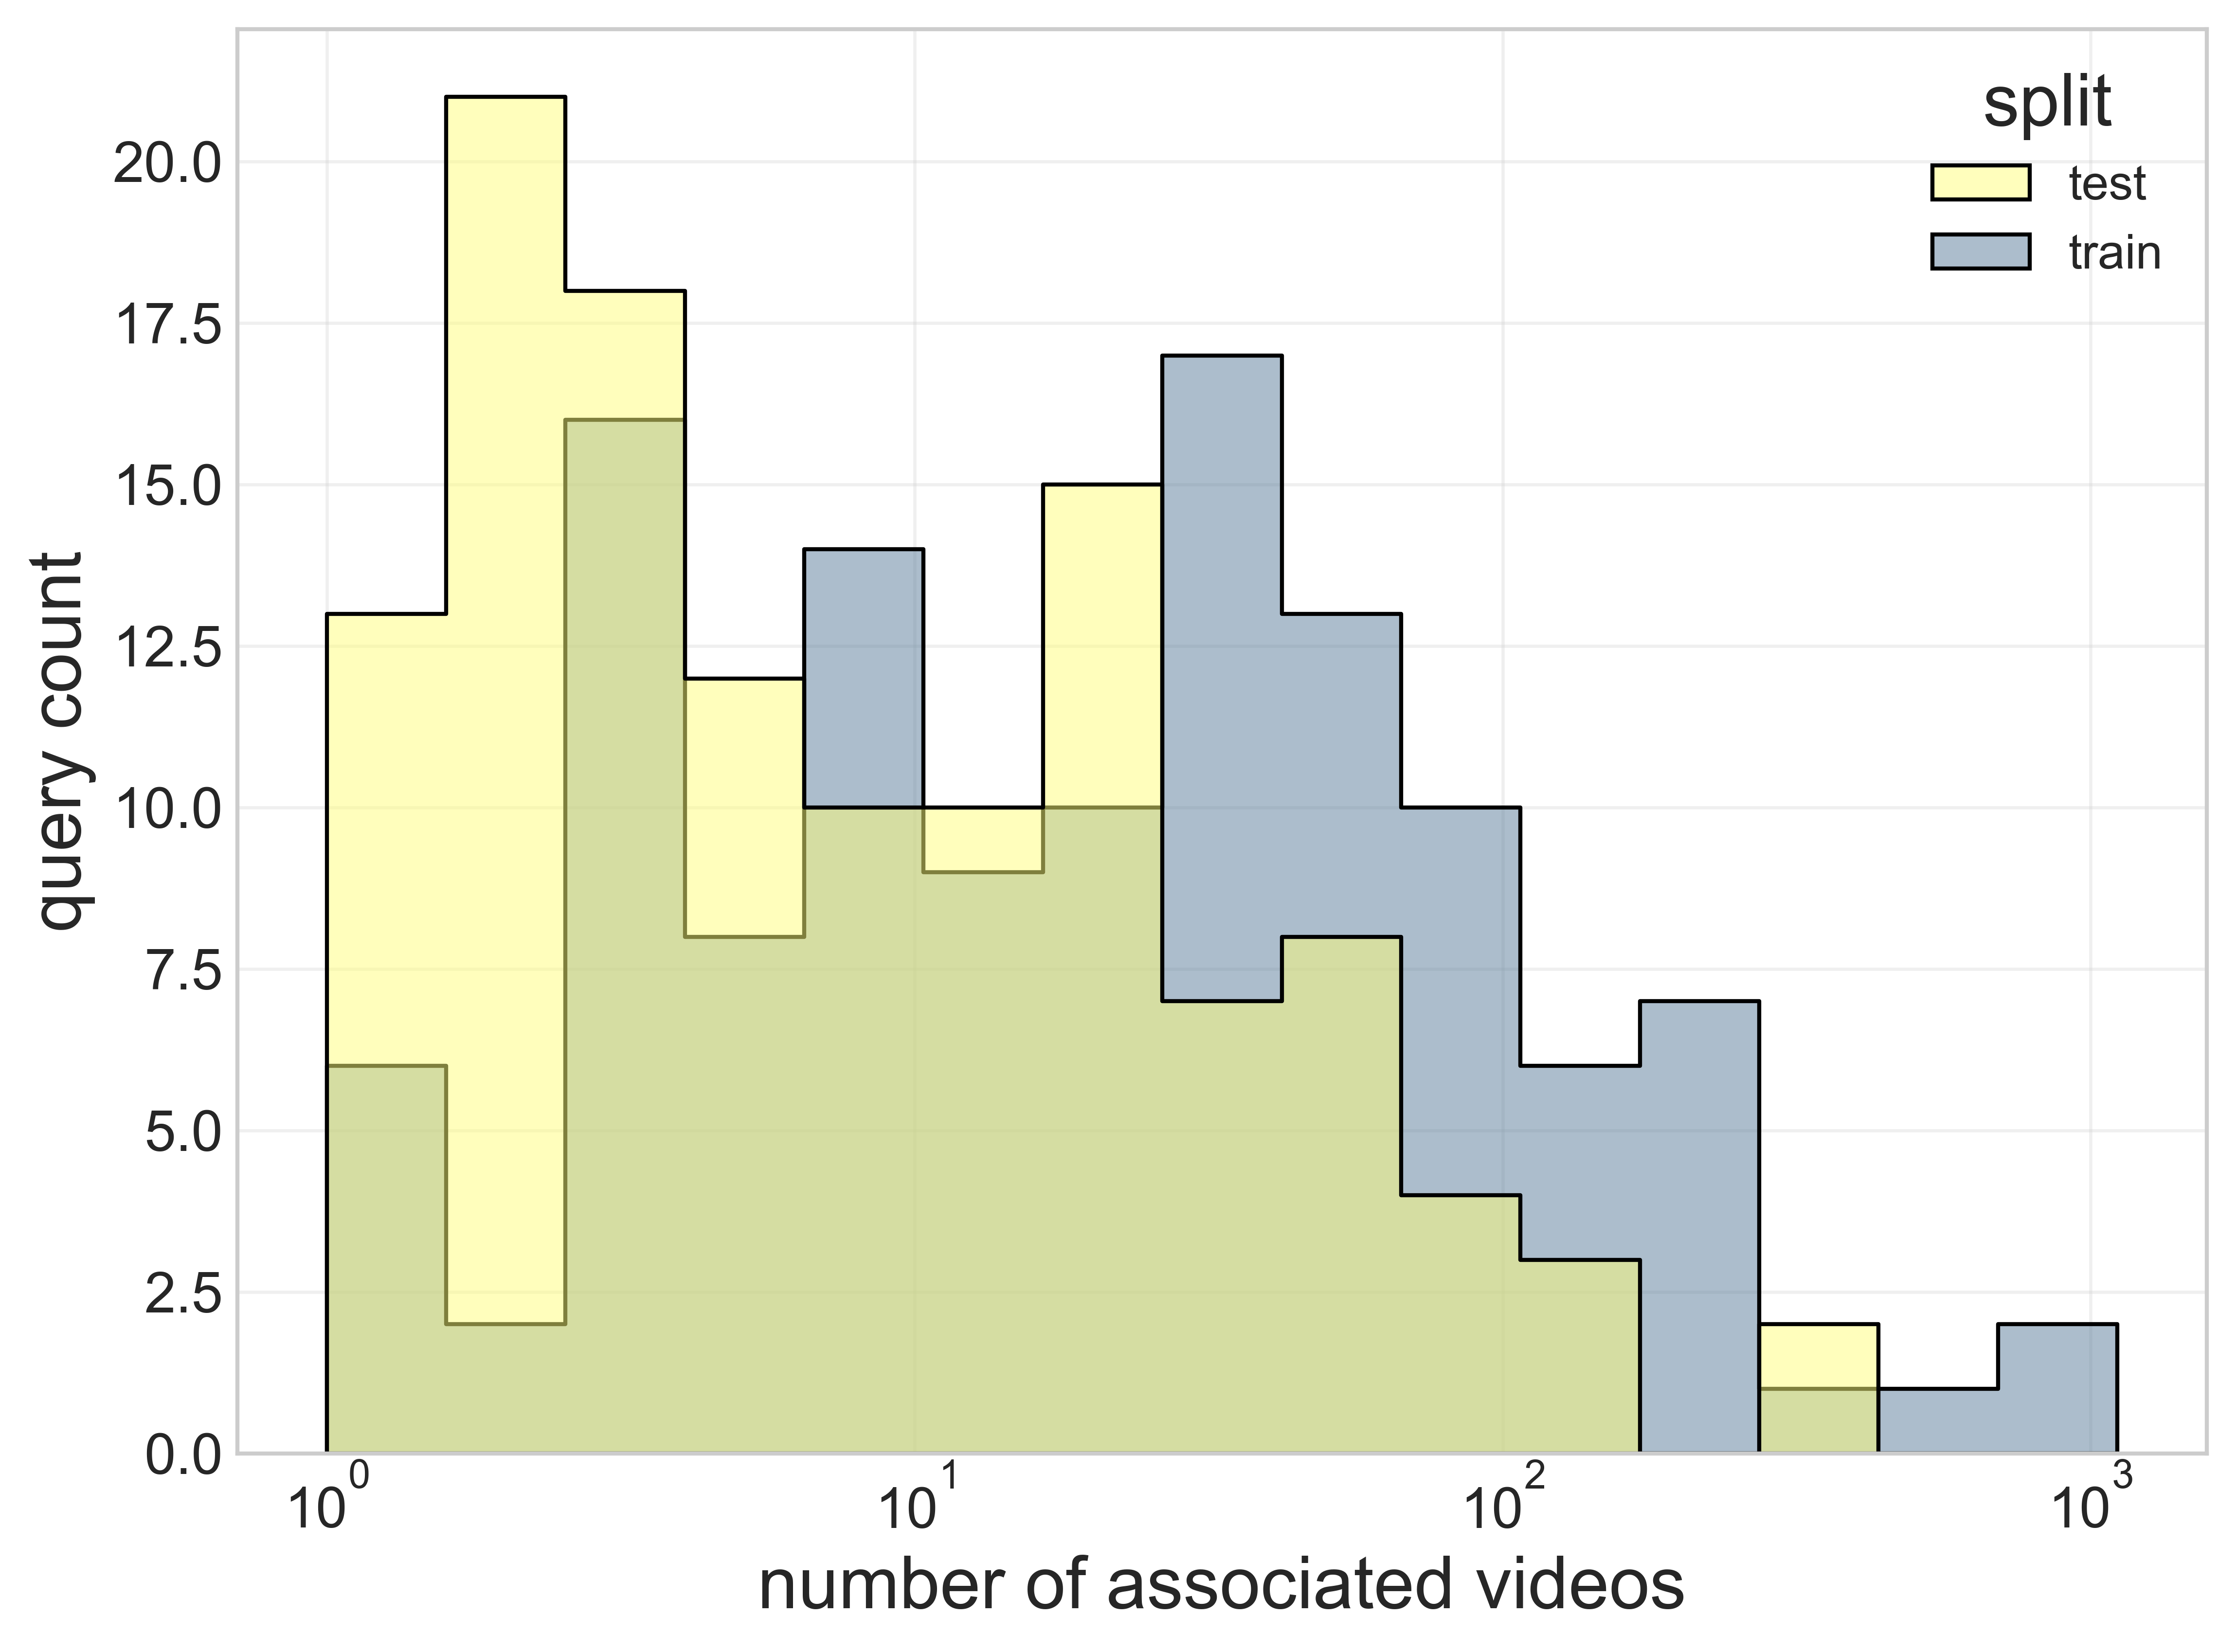

In [41]:
nb_videos_per_query_train = (queries_videos_train_df["nb_videos"].values)
nb_videos_per_query_test = (queries_videos_test_df["nb_videos"].values)

df = pd.DataFrame({
    "nb_videos": np.concatenate([nb_videos_per_query_test, nb_videos_per_query_train]),
    "split": ["test"] * len(nb_videos_per_query_test) + ["train"] * len(nb_videos_per_query_train)
})

# use a clean / conference‑style theme
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(data=df, x="nb_videos", hue="split", bins=15, multiple="layer",log_scale=True,
             palette=["xkcd:light yellow","xkcd:steel blue"], edgecolor="black", alpha=0.5, element="step")

ax.set_xlabel("number of associated videos", fontsize=18)
ax.set_ylabel("query count", fontsize=18)
ax.tick_params(axis="both", labelsize=14)

#ax.set_title("Distribution of videos per query", fontsize=16)

plt.tight_layout()
fig.savefig("nb_videos_per_query_hist_split.svg", transparent=True)
plt.show()

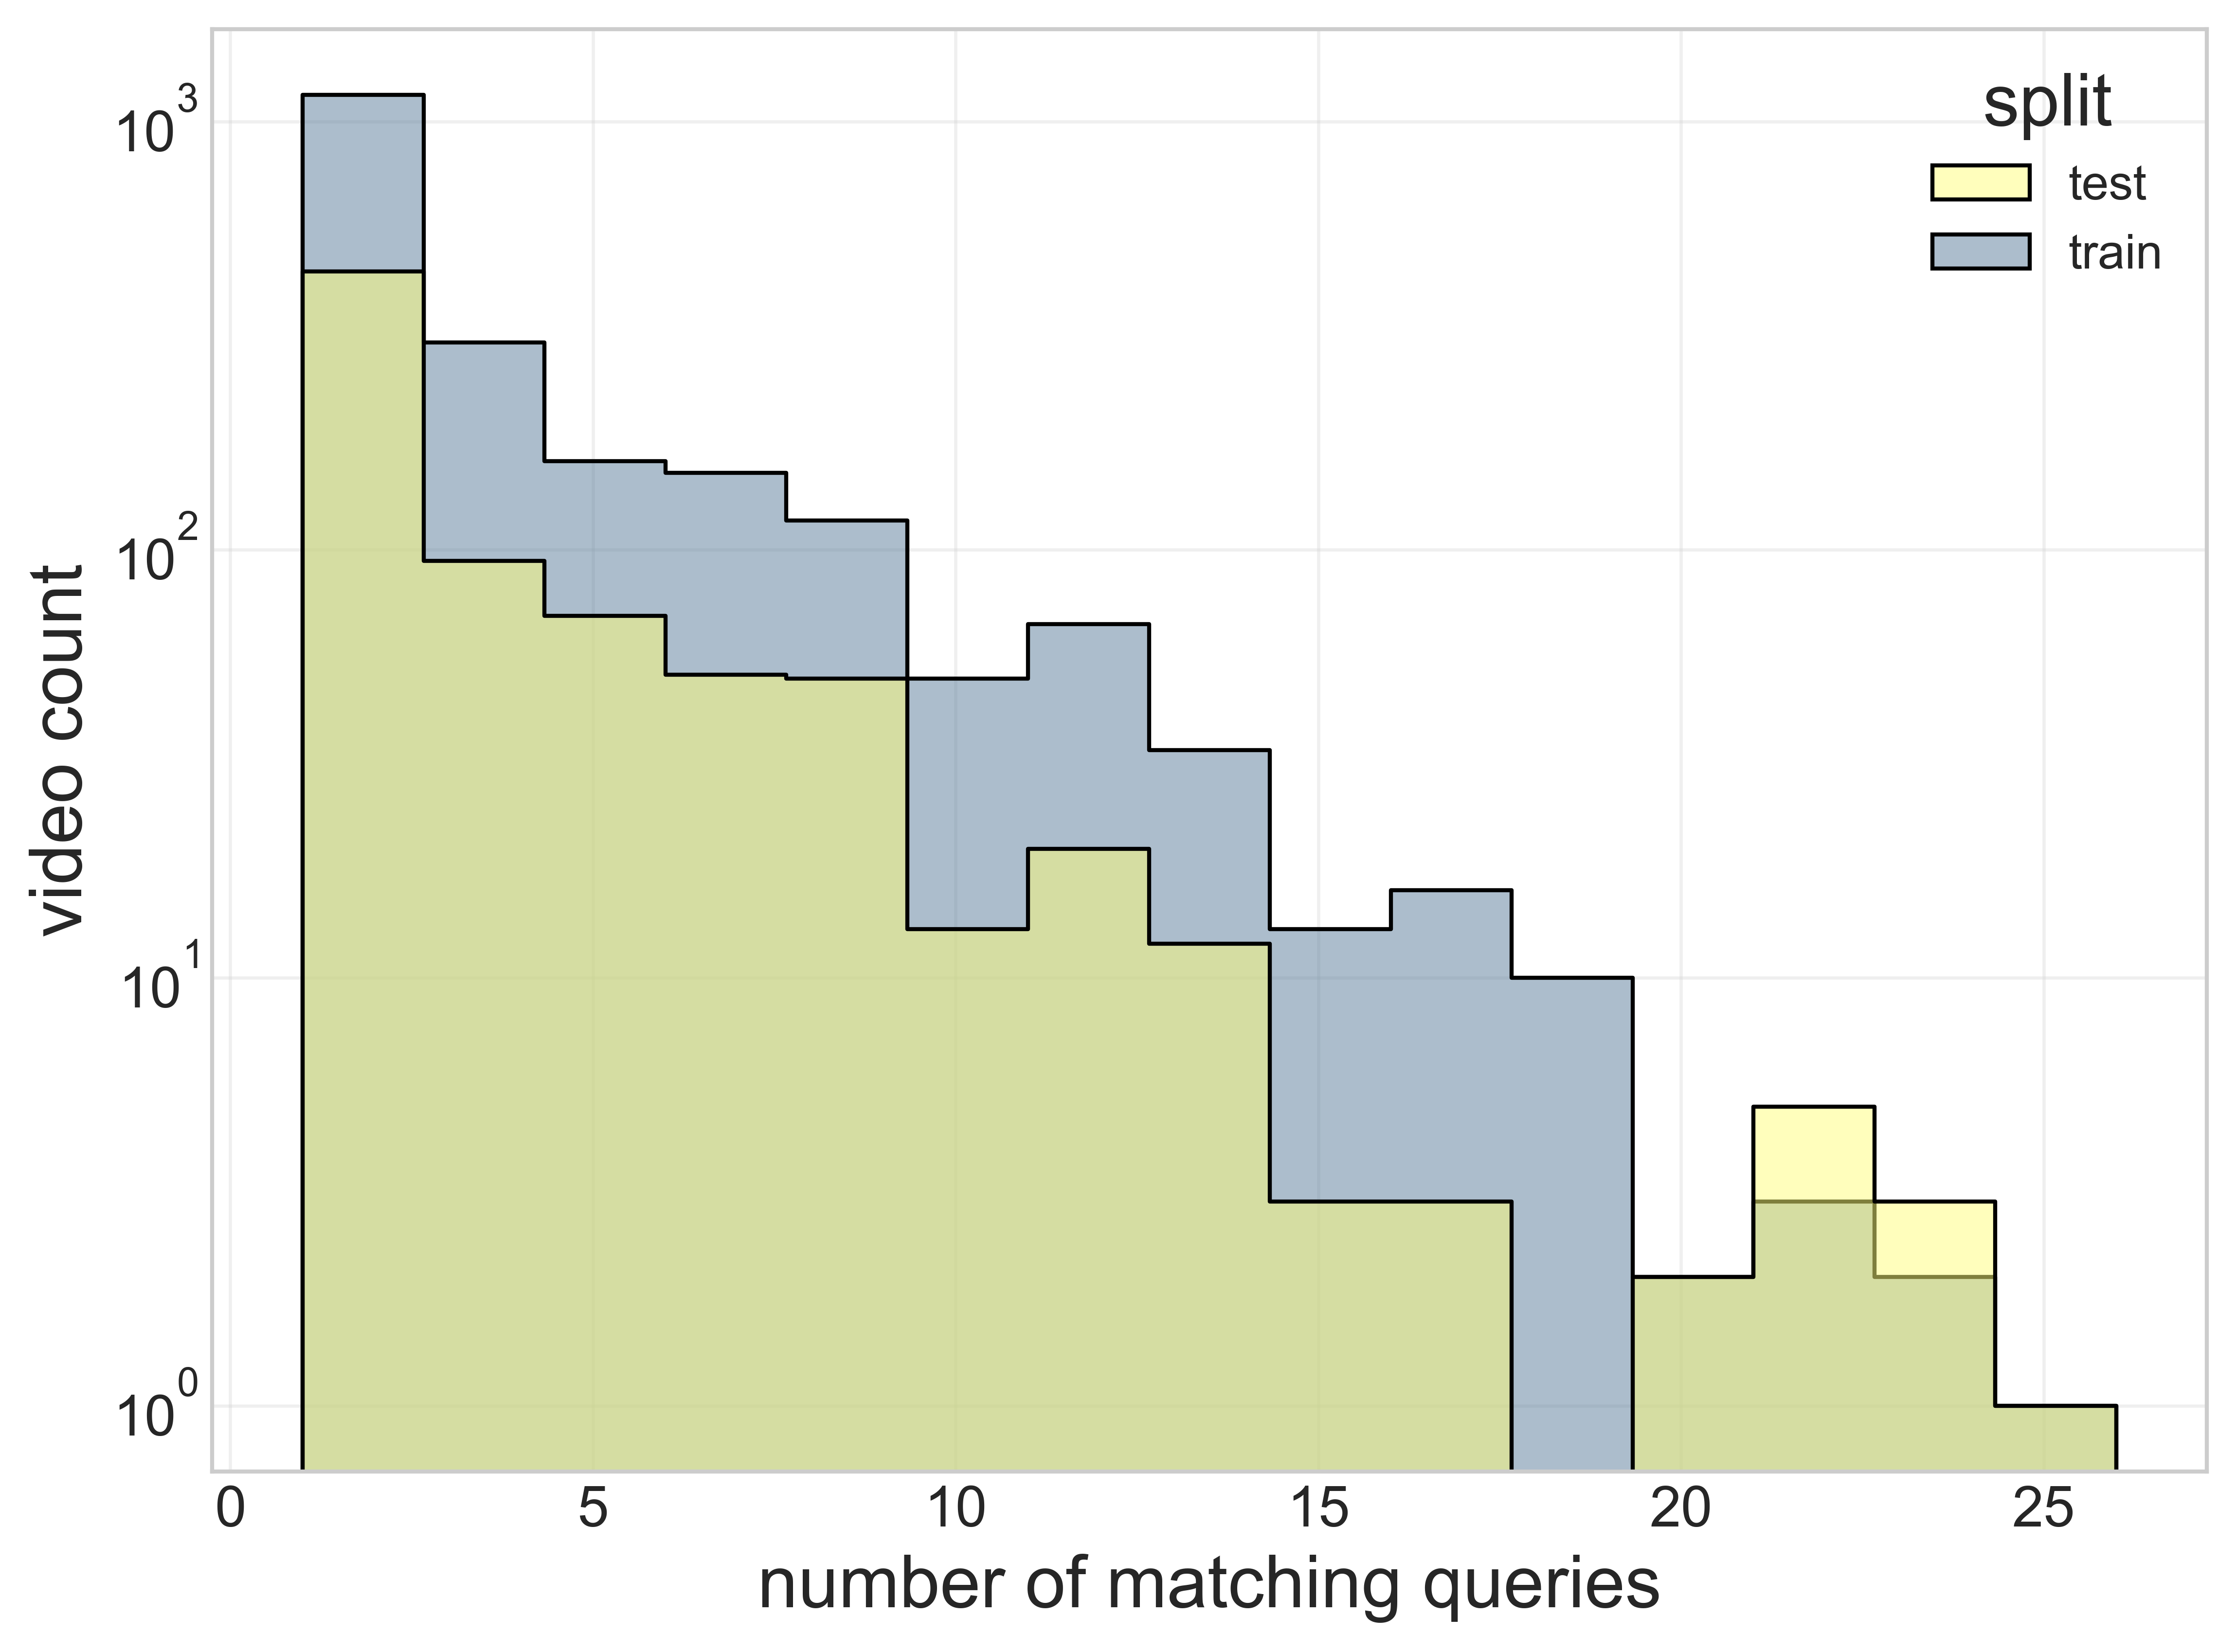

In [42]:
nb_queries_per_video_train = (queries_videos_train_df.explode("videos").groupby("videos").agg({"queries": pd.Series.nunique}).values).squeeze()
nb_queries_per_video_test = (queries_videos_test_df.explode("videos").groupby("videos").agg({"queries": pd.Series.nunique}).values).squeeze()

df = pd.DataFrame({
    "nb_queries": np.concatenate([nb_queries_per_video_test, nb_queries_per_video_train]),
    "split": ["test"] * len(nb_queries_per_video_test) + ["train"] * len(nb_queries_per_video_train)
})

# use a clean / conference‑style theme
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

g = sns.histplot(data=df, x="nb_queries", hue="split", bins=15, multiple="layer",log_scale=False,
             palette=["xkcd:light yellow","xkcd:steel blue"], edgecolor="black", alpha=0.5, element="step")

g.set_yscale("log")

ax.set_xlabel("number of matching queries", fontsize=18)
ax.set_ylabel("video count", fontsize=18)
ax.tick_params(axis="both", labelsize=14)
#ax.set_title("Distribution of queries per video", fontsize=16)

plt.tight_layout()
fig.savefig("nb_queries_per_video_hist_split.svg", transparent=True)
plt.show()

In [47]:
print(len(nb_videos_per_query_train[nb_videos_per_query_train==0]))
print(len(nb_videos_per_query_test[nb_videos_per_query_test==0]))

13
12


In [48]:
print(len(nb_queries_per_video_train[nb_queries_per_video_train==0]))
print(len(nb_queries_per_video_test[nb_queries_per_video_test==0]))

0
0
